In [1]:
channel_name = 'AiSeeKing'

In [2]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [3]:
def get_quota_reset_info():
    """Get information about when quota resets and suggest action"""
    from datetime import datetime, timezone, timedelta
    import pytz
    
    pacific = pytz.timezone('America/Los_Angeles')
    now_pt = datetime.now(pacific)
    
    # Calculate next reset time (midnight PT)
    reset_time = now_pt.replace(hour=0, minute=0, second=0, microsecond=0)
    if now_pt >= reset_time:
        reset_time += timedelta(days=1)
    
    time_until_reset = reset_time - now_pt
    hours_until_reset = time_until_reset.total_seconds() / 3600
    
    print(f"Current PT time: {now_pt.strftime('%H:%M')}")
    print(f"Quota resets in: {hours_until_reset:.1f} hours")
    
    if hours_until_reset < 4:
        print("⚠️  Caution: Limited time until quota reset")
        if hours_until_reset < 1:
            print("✅ Consider waiting for fresh quota")
    
    return hours_until_reset

# Use it like this:
if get_quota_reset_info() < 2:
    # Very little time until reset
    print("You might want to wait for quota reset")

Current PT time: 01:35
Quota resets in: 22.4 hours


In [4]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

In [5]:
channel_id = get_channel(channel_name)['id']['channelId']
channel_id

'UCfI2Wf-yji9reXIhn8U4jkQ'

# Diving into YouTube Analytics
Deepnote presented a live stream featuring a showcase of how to use Google's YouTube API. We had a few Deepnote coders and a Deepnote user Allan who helped crack the API and start getting data. Below is a project inspired from that stream!

In this notebook we are going to dive in and check out the popular YouTube channel Good Mythical Morning.

## API Functions
In this section we setup some API functions to help us gather data. We create a function to gather channel stats and video stats. To do this in a effecient way and save API calls we do not use the search function. We pull in GMM's upload playlist ( containing all of their videos ) and use that to build a video list. Then grab the data from each video.

In [8]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [9]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [10]:
# new function
def get_video_details(youtube, video_list):
    stats_list = []

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id 
            title = video['snippet']['title']
            published = video['snippet']['publishedAt']
            description = video['snippet']['description']
            view_count = video['statistics'].get('viewCount', 0)
            like_count = video['statistics'].get('likeCount', 0)
            dislike_count = video['statistics'].get('dislikeCount', 0)
            comment_count = video['statistics'].get('commentCount', 0)
            duration = video['contentDetails'].get('duration', 'Unknown')  # Use .get() with a default value

            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count,
                duration=duration             
            )
            stats_list.append(stats_dict)

    return stats_list

In [11]:
def convert_iso_duration_to_hms(duration):
    """
    Converts an ISO 8601 duration string (e.g., 'PT3M54S') to 'H:M:S' format.
    
    Args:
        duration (str): The ISO 8601 duration string (e.g., 'PT3M54S').
    
    Returns:
        str: The duration in 'H:M:S' format.
    """
    # Regex to extract hours, minutes, and seconds from the ISO 8601 duration
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return "0:00:00"  # Default if the format is invalid
    
    # Extract hours, minutes, and seconds
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    # Create a timedelta object
    delta = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    
    # Convert to total seconds
    total_seconds = int(delta.total_seconds())
    
    # Convert total seconds to H:M:S format
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    return f"{hours}:{minutes:02d}:{seconds:02d}"

## Create our Channel Stats

In [13]:
channel_stats = get_channel_stats(youtube, channel_id)

## Find our Upload Playlist ( will contain all video uploads )

In [15]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UUfI2Wf-yji9reXIhn8U4jkQ'

## Get our Video List

In [17]:
video_list = get_video_list(youtube, upload_id)

## Get our Video Details
## Finally we will get all of our videos details returned in a dictionary.

In [20]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 132'

## Pause and think what to do next

In [23]:
df=pd.DataFrame(video_data)
df.shape

(132, 9)

In [25]:
df['title_length'] = df['title'].str.len()
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["dislike_count"] = pd.to_numeric(df["dislike_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
df["published"] = pd.to_datetime(df["published"])
# Format the 'published' column to "%Y-%m-%d"
df["published"] = df["published"].dt.strftime("%Y-%m-%d")
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["dislike_count"] + df["comment_count"] + df["comment_count"]
df['hms_format'] = df['duration'].apply(convert_iso_duration_to_hms)

In [29]:
# Select rows where the title contains "Animation Maker"
#result = df
result = df.query('title.str.lower().str.contains("google|gemini")', engine='python')
result.shape

(34, 12)

In [31]:
cols = 'video_id title published view_count title_length hms_format'.split()

In [33]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(30)

Maximum title length: 100


,video_id,title,published,view_count,title_length,hms_format
5,jKYQZQUeuGM,Deepseek V3.2 Speciale might be the OPEN Gemini 3.0 Pro!,2025-12-01,8151,56,0:09:40
6,_mK2QnTi2fQ,Gemini 3 & Nano Banana 2.0 is Finally coming NEXT WEEK! My expectations & early checkpoint tests!,2025-11-15,3588,97,0:08:07
10,y5syTNGPynM,Gemini 3.0 Pro is coming this month. Everything you need to know before it!,2025-10-07,5078,75,0:08:19
13,eF_UGto8jKA,Google Chrome 2.0: Chrome just got new AI Agentic Features & IT'S AWESOME!,2025-09-19,6475,74,0:12:12
19,jSgylr1Eerw,Google's Gemini 2.5 Flash Image is ABSOLUTELY INSANE & FREE!,2025-08-26,4286,60,0:09:56
21,TsNykunxXuw,Gemini CLI is underrated.. Here's how I automate my life with it,2025-08-20,5586,64,0:08:02
22,Fb1xFGn0CtI,Google GemPix: Google JUST CRUSHED EVERY IMAGE MODEL YET! Use it for FREE Now!,2025-08-17,7793,78,0:08:12
26,_SlBE_w9Vd4,"Claude 4.1 Opus, Gemini 3 is coming this week & You can use GPT-5 / GPT-OSS right now on Windsurf!",2025-08-05,11295,98,0:08:05
29,MBAM8DFi04U,Google Opal: This is the MOST AMAZING FULLY FREE App Generator!,2025-07-26,16286,63,0:08:33
34,odA-gDzU_Ec,"Gemini 3 is coming, Google Acquired Windsurf & OpenAI's Open model is now delayed!",2025-07-12,10256,82,0:11:12


## Most Viewed Videos

In [36]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:94]
df_highest_views['view_count_millions'] = df_highest_views['view_count'] / 1000
df_highest_views[cols]

,video_id,title,published,view_count,title_length,hms_format
29,MBAM8DFi04U,Google Opal: This is the MOST AMAZING FULLY FREE App Generator!,2025-07-26,16286,63,0:08:33
78,hhvZh57-IPY,Gemini 2.5 ULTRA - Nightwhisper (Fully Tested): Google's OWN NEW AI Model now beats GEMINI 2.5,2025-04-03,13110,100,0:08:14
51,X4AzE7Gf7Y0,Google AI Edge App: LM-Studio for Smartphone! This OPENSOURCE AI App by Google is INSANE!,2025-05-28,13095,89,0:09:11
49,0oso_xcm46M,Google just OPENSOURCED their Deep Research Tool & You can now use it LOCALLY!,2025-06-03,11748,78,0:08:35
26,_SlBE_w9Vd4,"Claude 4.1 Opus, Gemini 3 is coming this week & You can use GPT-5 / GPT-OSS right now on Winds",2025-08-05,11295,98,0:08:05
43,urPPGABegAk,Gemini's 3 NEW Models are launching today!,2025-06-17,11143,42,0:08:27
35,bS0ylEjrr8w,Grok 4 or Claude 4 Sonnet or Gemini 2.5 Pro?,2025-07-10,10989,44,0:08:26
34,odA-gDzU_Ec,"Gemini 3 is coming, Google Acquired Windsurf & OpenAI's Open model is now delayed!",2025-07-12,10256,82,0:11:12
71,Oq7b-L9ISXw,o4-mini or Gemini 2.5 Pro? (& Gemini 2.5 Coder is COMING!),2025-04-17,9721,58,0:08:05
47,llwYDHQ133E,Google just OFFICIALLY REVEALED Gemini's 2025 Roadmap! (& RIP Google's AI Studio),2025-06-07,9012,81,0:08:55


In [1]:
df_highest_views[cols].sort_values(by="published",ascending=False)

NameError: name 'df_highest_views' is not defined

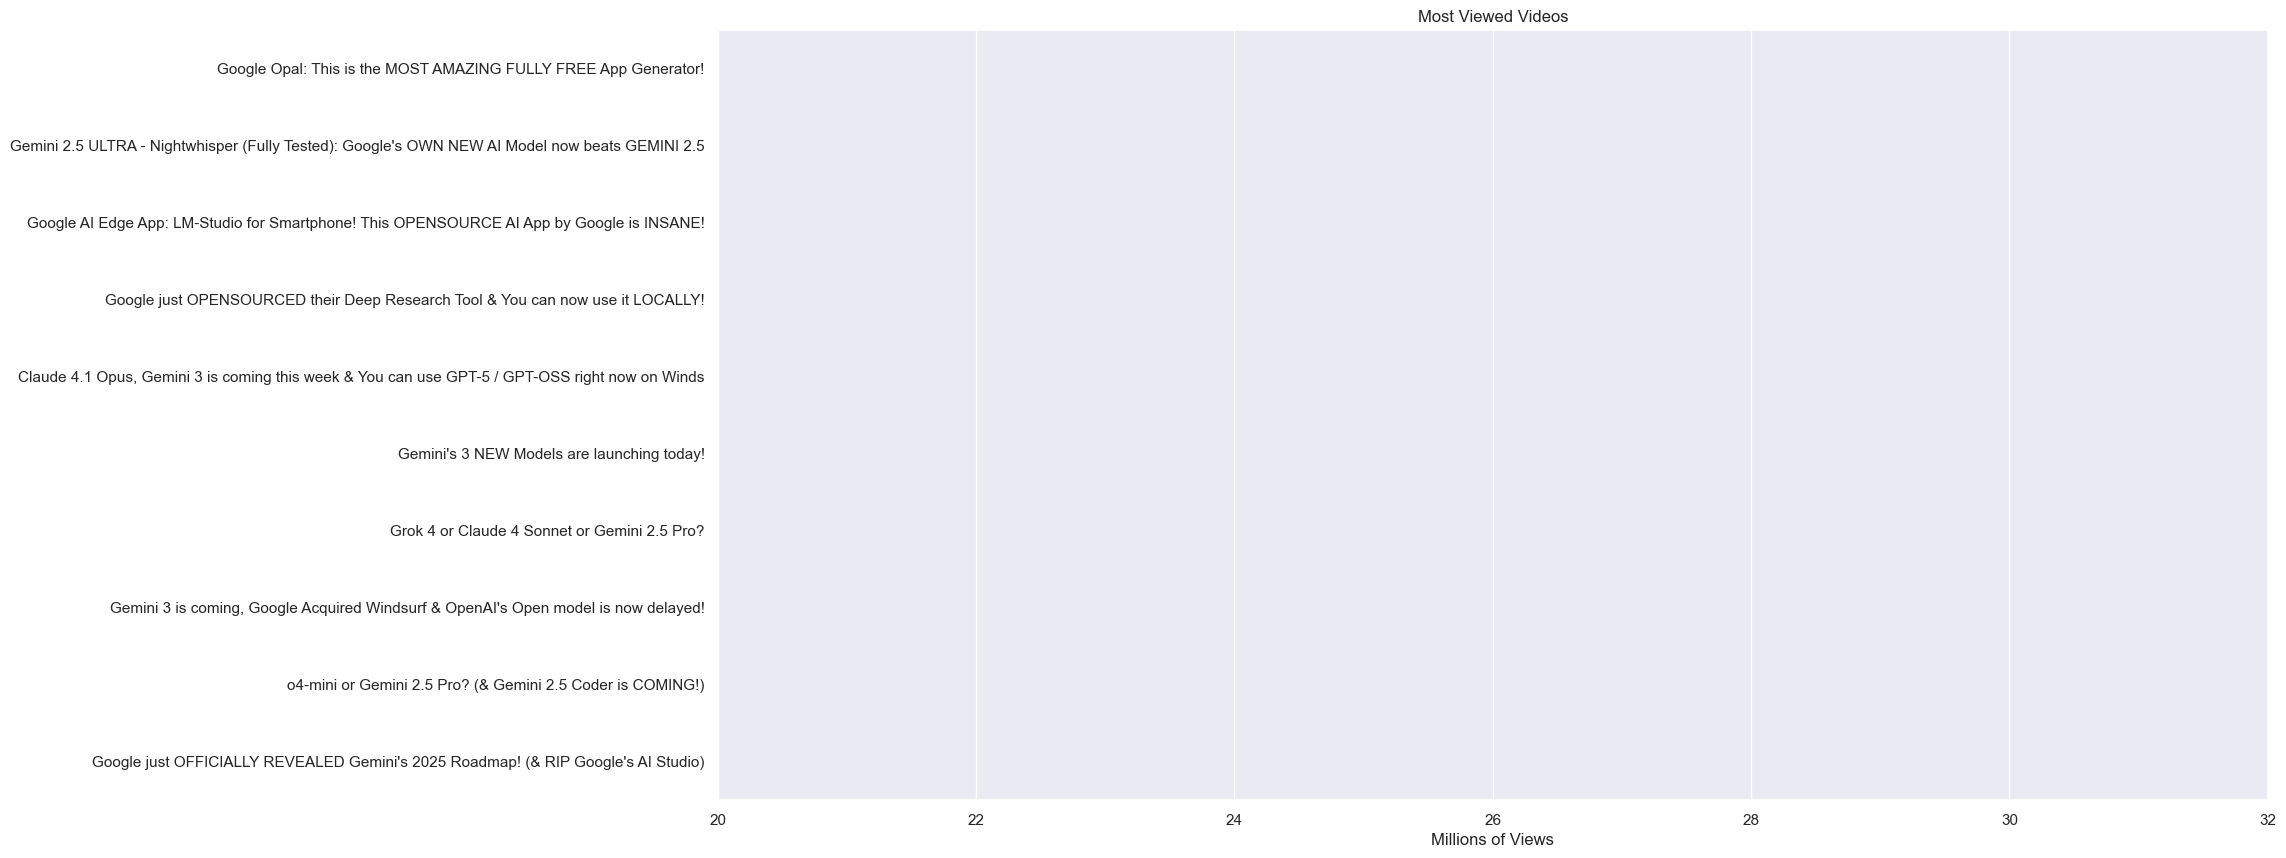

In [38]:
# Set the figure size
sns.set(rc={'figure.figsize': (20, 10)})

# Create the barplot
plot = sns.barplot(
    x="view_count_millions", 
    y="title", 
    hue="title",  # Assign y variable to hue
    data=df_highest_views, 
    palette="bright", 
    legend=False  # Disable the legend
)

# Set labels and title
plot.set(xlabel='Millions of Views', ylabel='')
plot.set_title('Most Viewed Videos')

# Set x-axis limits
plt.xlim(20, 32)

# Show the plot
plt.show()

In [40]:
colt = 'video_id title published view_count hms_format'.split()
output_file = channel_name + '.csv'
result[colt].to_csv(output_file, index=None)
result[colt].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,hms_format
5,jKYQZQUeuGM,Deepseek V3.2 Speciale might be the OPEN Gemini 3.0 Pro!,2025-12-01,8151,0:09:40
6,_mK2QnTi2fQ,Gemini 3 & Nano Banana 2.0 is Finally coming NEXT WEEK! My expectations & early checkpoint tests!,2025-11-15,3588,0:08:07
10,y5syTNGPynM,Gemini 3.0 Pro is coming this month. Everything you need to know before it!,2025-10-07,5078,0:08:19
13,eF_UGto8jKA,Google Chrome 2.0: Chrome just got new AI Agentic Features & IT'S AWESOME!,2025-09-19,6475,0:12:12
19,jSgylr1Eerw,Google's Gemini 2.5 Flash Image is ABSOLUTELY INSANE & FREE!,2025-08-26,4286,0:09:56
21,TsNykunxXuw,Gemini CLI is underrated.. Here's how I automate my life with it,2025-08-20,5586,0:08:02
22,Fb1xFGn0CtI,Google GemPix: Google JUST CRUSHED EVERY IMAGE MODEL YET! Use it for FREE Now!,2025-08-17,7793,0:08:12
26,_SlBE_w9Vd4,"Claude 4.1 Opus, Gemini 3 is coming this week & You can use GPT-5 / GPT-OSS right now on Windsurf!",2025-08-05,11295,0:08:05
29,MBAM8DFi04U,Google Opal: This is the MOST AMAZING FULLY FREE App Generator!,2025-07-26,16286,0:08:33
34,odA-gDzU_Ec,"Gemini 3 is coming, Google Acquired Windsurf & OpenAI's Open model is now delayed!",2025-07-12,10256,0:11:12


In [42]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [44]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [46]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\AiSeeKing.xlsx'

In [48]:
colt = 'video_id title published view_count hms_format read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)